# Chapter 8 — Word-Level Tokenization

Chapter 7 built an exact character-level tokenizer.

That tokenizer has a small vocabulary, but ordinary sentences become long token sequences.

This chapter explores the opposite tradeoff by treating word-like pieces as tokens.

By the end of the chapter, you will be able to:

- compare whitespace and punctuation-aware tokenization;
- build and use a word-level vocabulary;
- distinguish a token-level round trip from exact text reconstruction;
- handle unseen tokens with an explicit unknown token; and
- explain why word-level limitations motivate subword tokenization.

## What Word-Level Tokenization Means

A **word-level tokenizer** treats word-like pieces as tokens.

For example, `The dog ran.` might become:

```python
["The", "dog", "ran", "."]
```

This sequence is shorter than the corresponding character sequence.

The name *word-level* is convenient, but punctuation and special markers can also be tokens.

Every tokenizer must define both how text is split and which tokens its vocabulary recognizes.

## Use the Prepared Text from Chapter 7

The fixture preserves capitalization, punctuation, line breaks, and a paragraph break.

Using the same fixture makes the tokenization tradeoffs directly comparable with Chapter 7.

In [1]:
prepared_text = (
    "The dog ran across the yard.\n"
    "The cat sat near the window.\n"
    "\n"
    "The dog looked at the cat!\n"
    "The cat looked back."
)

print(prepared_text)
print()
print("Representation:", repr(prepared_text))

The dog ran across the yard.
The cat sat near the window.

The dog looked at the cat!
The cat looked back.

Representation: 'The dog ran across the yard.\nThe cat sat near the window.\n\nThe dog looked at the cat!\nThe cat looked back.'


## Start with Whitespace Tokenization

Python's `str.split()` separates text at runs of whitespace.

Spaces, tabs, and newlines act as separators and are not retained as tokens.

This makes `.split()` a useful baseline rather than a complete tokenizer.

In [2]:
def tokenize_by_whitespace(text: str) -> list[str]:
    return text.split()


whitespace_tokens = tokenize_by_whitespace(prepared_text)

print("Whitespace tokens:")
print(whitespace_tokens)
print("Token count:", len(whitespace_tokens))

Whitespace tokens:
['The', 'dog', 'ran', 'across', 'the', 'yard.', 'The', 'cat', 'sat', 'near', 'the', 'window.', 'The', 'dog', 'looked', 'at', 'the', 'cat!', 'The', 'cat', 'looked', 'back.']
Token count: 22


The output reveals two immediate consequences:

- punctuation remains attached, so `yard.` and `yard` would be different tokens;
- the paragraph break disappears because the separators were discarded.

Different whitespace patterns can therefore produce the same token list.

In [3]:
whitespace_variants = [
    "The dog",
    "The   dog",
    "The\tdog",
    "The\ndog",
]

for text in whitespace_variants:
    print(f"{text!r:12} -> {tokenize_by_whitespace(text)}")

'The dog'    -> ['The', 'dog']
'The   dog'  -> ['The', 'dog']
'The\tdog'   -> ['The', 'dog']
'The\ndog'   -> ['The', 'dog']


## Build a Vocabulary and Token-ID Mappings

A **vocabulary** is the collection of distinct tokens the tokenizer recognizes.

Sorting the tokens gives this educational tokenizer a deterministic ID assignment.

The IDs are labels only, just as character IDs were in Chapter 7.

In [4]:
def build_token_vocabulary(tokens: list[str]) -> list[str]:
    return sorted(set(tokens))


def build_token_mappings(
    vocabulary: list[str],
) -> tuple[dict[str, int], dict[int, str]]:
    token_to_id = {token: token_id for token_id, token in enumerate(vocabulary)}
    id_to_token = {token_id: token for token, token_id in token_to_id.items()}
    return token_to_id, id_to_token


whitespace_vocabulary = build_token_vocabulary(whitespace_tokens)
whitespace_token_to_id, whitespace_id_to_token = build_token_mappings(
    whitespace_vocabulary
)

for token, token_id in whitespace_token_to_id.items():
    print(f"{token_id:>2}: {token!r}")

 0: 'The'
 1: 'across'
 2: 'at'
 3: 'back.'
 4: 'cat'
 5: 'cat!'
 6: 'dog'
 7: 'looked'
 8: 'near'
 9: 'ran'
10: 'sat'
11: 'the'
12: 'window.'
13: 'yard.'


## Encode and Decode Tokens

Encoding replaces each token with its vocabulary ID.

Decoding reverses that mapping and should recover the tokenizer's token sequence exactly.

Both functions fail clearly when given an unknown token or ID.

In [5]:
def encode_tokens(tokens: list[str], token_to_id: dict[str, int]) -> list[int]:
    token_ids = []

    for position, token in enumerate(tokens):
        if token not in token_to_id:
            raise ValueError(
                f"Cannot encode token {token!r} at token position {position}."
            )
        token_ids.append(token_to_id[token])

    return token_ids


def decode_token_ids(
    token_ids: list[int],
    id_to_token: dict[int, str],
) -> list[str]:
    tokens = []

    for position, token_id in enumerate(token_ids):
        if token_id not in id_to_token:
            raise ValueError(
                f"Cannot decode token ID {token_id} at position {position}."
            )
        tokens.append(id_to_token[token_id])

    return tokens

In [6]:
whitespace_token_ids = encode_tokens(
    whitespace_tokens,
    whitespace_token_to_id,
)
decoded_whitespace_tokens = decode_token_ids(
    whitespace_token_ids,
    whitespace_id_to_token,
)

assert decoded_whitespace_tokens == whitespace_tokens

print("Token IDs:", whitespace_token_ids)
print("Decoded tokens:", decoded_whitespace_tokens)

Token IDs: [0, 6, 9, 1, 11, 13, 0, 4, 10, 8, 11, 12, 0, 6, 7, 2, 11, 5, 0, 4, 7, 3]
Decoded tokens: ['The', 'dog', 'ran', 'across', 'the', 'yard.', 'The', 'cat', 'sat', 'near', 'the', 'window.', 'The', 'dog', 'looked', 'at', 'the', 'cat!', 'The', 'cat', 'looked', 'back.']


The token-level round trip succeeds because every token maps back to itself.

Rejoining those tokens with spaces does not recover the original text because the original whitespace was discarded.

In [7]:
decoded_whitespace_text = " ".join(decoded_whitespace_tokens)

print("Decoded text:")
print(decoded_whitespace_text)
print()
print("Exact text match:", decoded_whitespace_text == prepared_text)

Decoded text:
The dog ran across the yard. The cat sat near the window. The dog looked at the cat! The cat looked back.

Exact text match: False


This tokenizer is **lossy at the text level** because encoding does not preserve enough information to reconstruct exact formatting.

Readable output and exact reconstruction are different guarantees.

## Separate Words from Punctuation

A punctuation-aware tokenizer can represent sentence punctuation independently from neighboring words.

The next toy tokenizer recognizes runs of English letters, runs of digits, and individual punctuation symbols.

It is deliberately limited: it does not preserve whitespace, and its English-letter rule does not cover general Unicode text.

In [8]:
import re


def tokenize_words_and_punctuation(text: str) -> list[str]:
    return re.findall(r"[A-Za-z]+|[0-9]+|[^\w\s]", text)


punctuation_aware_tokens = tokenize_words_and_punctuation(prepared_text)

print(punctuation_aware_tokens)
print("Token count:", len(punctuation_aware_tokens))

['The', 'dog', 'ran', 'across', 'the', 'yard', '.', 'The', 'cat', 'sat', 'near', 'the', 'window', '.', 'The', 'dog', 'looked', 'at', 'the', 'cat', '!', 'The', 'cat', 'looked', 'back', '.']
Token count: 26


The period and exclamation mark now have their own positions in the sequence.

This avoids creating separate vocabulary entries such as `yard.` and `yard`.

Capitalized `The` and lowercase `the` remain distinct because the tokenizer preserves case.

In [9]:
punctuation_vocabulary = build_token_vocabulary(punctuation_aware_tokens)
punctuation_token_to_id, punctuation_id_to_token = build_token_mappings(
    punctuation_vocabulary
)
punctuation_token_ids = encode_tokens(
    punctuation_aware_tokens,
    punctuation_token_to_id,
)

print("Vocabulary:")
for token, token_id in punctuation_token_to_id.items():
    print(f"{token_id:>2}: {token!r}")

Vocabulary:
 0: '!'
 1: '.'
 2: 'The'
 3: 'across'
 4: 'at'
 5: 'back'
 6: 'cat'
 7: 'dog'
 8: 'looked'
 9: 'near'
10: 'ran'
11: 'sat'
12: 'the'
13: 'window'
14: 'yard'


## Decode into Readable Text

Joining every token with a space places unwanted spaces before punctuation.

The display helper below removes spaces before a small, explicit set of punctuation marks.

It improves readability but cannot restore paragraph breaks that tokenization discarded.

In [10]:
def decode_tokens_to_readable_text(tokens: list[str]) -> str:
    text = " ".join(tokens)

    for punctuation_mark in [".", ",", "!", "?", ";", ":"]:
        text = text.replace(f" {punctuation_mark}", punctuation_mark)

    return text


decoded_punctuation_tokens = decode_token_ids(
    punctuation_token_ids,
    punctuation_id_to_token,
)
decoded_punctuation_text = decode_tokens_to_readable_text(decoded_punctuation_tokens)

assert decoded_punctuation_tokens == punctuation_aware_tokens

print(decoded_punctuation_text)
print()
print("Exact text match:", decoded_punctuation_text == prepared_text)

The dog ran across the yard. The cat sat near the window. The dog looked at the cat! The cat looked back.

Exact text match: False


## Compare the Two Tokenizers

The punctuation-aware tokenizer creates a few more tokens because punctuation becomes separate.

Its vocabulary is cleaner because the same word does not need separate entries for attached punctuation.

In [11]:
tokenizer_comparison = [
    (
        "characters",
        len(prepared_text),
        len(set(prepared_text)),
    ),
    (
        "whitespace",
        len(whitespace_tokens),
        len(whitespace_vocabulary),
    ),
    (
        "words + punctuation",
        len(punctuation_aware_tokens),
        len(punctuation_vocabulary),
    ),
]

print(f"{'tokenizer':<22} {'tokens':>8} {'vocabulary':>12}")
print("-" * 44)
for name, token_count, vocabulary_size in tokenizer_comparison:
    print(f"{name:<22} {token_count:>8} {vocabulary_size:>12}")

tokenizer                tokens   vocabulary
--------------------------------------------
characters                  106           22
whitespace                   22           14
words + punctuation          26           15


The table separates **sequence length** from **vocabulary size**.

Character tokenization uses many sequence positions but relatively few token types.

Word-level tokenization shortens the sequence while requiring a distinct vocabulary entry for each recognized word form.

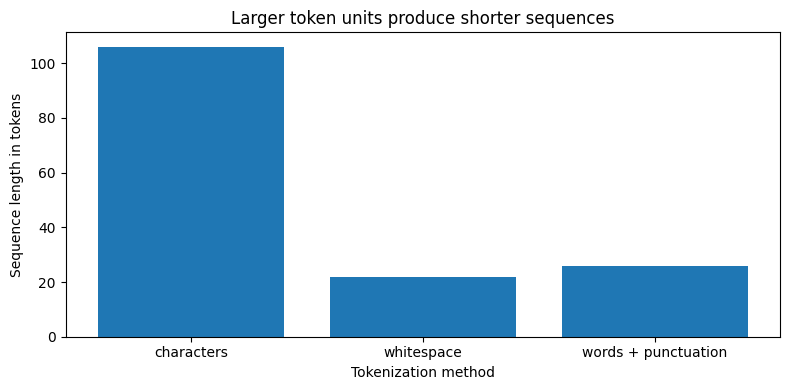

In [12]:
import matplotlib.pyplot as plt  # noqa: I001


tokenizer_names = [row[0] for row in tokenizer_comparison]
token_counts = [row[1] for row in tokenizer_comparison]

plt.figure(figsize=(8, 4))
plt.bar(tokenizer_names, token_counts)
plt.xlabel("Tokenization method")
plt.ylabel("Sequence length in tokens")
plt.title("Larger token units produce shorter sequences")
plt.tight_layout()
plt.show()

The plot isolates one relationship: larger text units represent this fixture with fewer sequence positions.

It does not claim that the shortest sequence is automatically the best representation.

## The Unknown-Word Problem

A fixed word-level vocabulary cannot encode a new word unless that exact token is already present.

The fixture vocabulary knows `The` and `.`, but it does not know `bird` or `flew`.

In [13]:
new_text = "The bird flew."
new_tokens = tokenize_words_and_punctuation(new_text)

print("New tokens:", new_tokens)

try:
    encode_tokens(new_tokens, punctuation_token_to_id)
except ValueError as error:
    print("Expected error:", error)

New tokens: ['The', 'bird', 'flew', '.']
Expected error: Cannot encode token 'bird' at token position 1.


An **unknown token** provides an explicit fallback for vocabulary items that were not seen during vocabulary construction.

We will use the special token `<unknown>` and reserve its ID before encoding new text.

In [14]:
UNKNOWN_TOKEN = "<unknown>"

if UNKNOWN_TOKEN in punctuation_vocabulary:
    raise ValueError("The special unknown token collides with a corpus token.")

vocabulary_with_unknown = [UNKNOWN_TOKEN, *punctuation_vocabulary]
token_to_id_with_unknown, id_to_token_with_unknown = build_token_mappings(
    vocabulary_with_unknown
)


def encode_tokens_with_unknown(
    tokens: list[str],
    token_to_id: dict[str, int],
    unknown_token: str,
) -> list[int]:
    if unknown_token not in token_to_id:
        raise ValueError("The unknown token must exist in the vocabulary.")

    unknown_token_id = token_to_id[unknown_token]
    return [token_to_id.get(token, unknown_token_id) for token in tokens]

In [15]:
new_token_ids = encode_tokens_with_unknown(
    new_tokens,
    token_to_id_with_unknown,
    UNKNOWN_TOKEN,
)
decoded_new_tokens = decode_token_ids(
    new_token_ids,
    id_to_token_with_unknown,
)

print("Original tokens:", new_tokens)
print("Token IDs:", new_token_ids)
print("Decoded tokens:", decoded_new_tokens)

Original tokens: ['The', 'bird', 'flew', '.']
Token IDs: [3, 0, 0, 2]
Decoded tokens: ['The', '<unknown>', '<unknown>', '.']


Both `bird` and `flew` become the same `<unknown>` token.

Encoding can continue, but the original words cannot be recovered or distinguished after that replacement.

An unknown token is therefore a fallback, not a complete solution to unseen words.

## Related Words Still Use Separate IDs

A simple word-level tokenizer does not expose the shared structure of related word forms.

Each distinct form requires its own vocabulary entry.

In [16]:
related_word_text = "look looks looked looking run runs ran running"
related_word_tokens = tokenize_words_and_punctuation(related_word_text)
related_word_vocabulary = build_token_vocabulary(related_word_tokens)

print("Tokens:", related_word_tokens)
print("Vocabulary size:", len(related_word_vocabulary))
print("Vocabulary:", related_word_vocabulary)

Tokens: ['look', 'looks', 'looked', 'looking', 'run', 'runs', 'ran', 'running']
Vocabulary size: 8
Vocabulary: ['look', 'looked', 'looking', 'looks', 'ran', 'run', 'running', 'runs']


## Why Subword Tokenization Follows

Character-level and word-level tokenization solve opposite problems.

- Character tokens keep the vocabulary small and can compose unseen words, but they create long sequences.
- Word-like tokens create shorter sequences, but their vocabularies grow quickly and still encounter unseen words.

Subword tokenization seeks a middle ground by representing frequent pieces as tokens and composing less familiar words from smaller pieces.

For example, a future tokenizer might share `look` across `looked` and `looking` instead of assigning every form an unrelated token.

## Takeaways

- Whitespace tokenization is a useful baseline, but it discards whitespace and attaches punctuation to words.
- Punctuation-aware tokenization creates cleaner word-like tokens while remaining lossy in this toy implementation.
- Token-level round trips can succeed even when exact text reconstruction fails.
- Fixed word vocabularies cannot represent unseen words directly.
- A single unknown token allows encoding to continue but erases the identity of every replaced token.
- Word-level sequence efficiency comes with vocabulary growth and poor handling of novel forms.

The next chapter will use these limitations to motivate subword tokenization more carefully.